# T14 — Igneous zircons through deep time

**Wu et al. 2023 (https://doi.org/10.5281/zenodo.7795705) igneous zircons reconstructed through the Cao et al. 2024 1.8 Ga plate model, rendered as individual large pyGMT maps plus an interactive Panel slider.**

## What this notebook produces

Igneous zircons crystallize from cooling magma, so each one is a direct rock-record fingerprint of magmatism at a specific time and place. The Wu et al. (2023) global zircon U-Pb geochronology database compiles thousands of igneous zircon samples spanning the deep-time interval. The Cao et al. (2024) plate-tectonic reconstruction covers exactly the same interval. Combining the two lets us reconstruct each igneous zircon to where its parent magma sat at the time of crystallization \u2014 a window onto paleo-magmatic flare-ups along arcs, rifts, and large igneous provinces.

This notebook renders six large individual paleo-Earth maps at representative ages (50, 150, 250, 450, 900, 1500 Ma) and finishes with a T07-style Panel interactive slider that scrubs through all of deep time. This notebook is inspired by Jian, Williams, Yu & Zhao (2022, JGR-Solid Earth, doi:10.1029/2022JB024606), who first reconstructed the global detrital-zircon record onto a plate-tectonic framework. The implementation here is independent: it uses only the Wu 2023 database, the Cao 2024 deep-time model via `plate_model_manager`, and stock `gplately` + `pyGMT` workflows.

**Audience**: postgrad.  
**Difficulty**: ★★★.

## Learning objectives

By the end of this notebook you can:
- Load igneous-zircon point features from a GPlates `.gpmlz` collection.
- Reconstruct a population of point features to an arbitrary age using their pre-assigned plate IDs.
- Render large publication-style paleo-Earth maps with `pygmt`, layering reconstructed continents, plate boundaries (continuous-backbone pattern), subduction teeth, and the zircon dots themselves.
- Wrap a `pygmt`-generated map series into a Panel widget for interactive temporal exploration.

## Prerequisites

Bundled data: `EarthByteWorkflows-master_April2026/Zircon_Database/Wu_global_zircon_database_2023/script_data/zircons_igneous_Wu2023.gpmlz` (reached via standard candidate paths). Cao 2024 is fetched on demand via `plate_model_manager`. Panel must be installed (`conda install -c conda-forge panel`). Pre-rendering the interactive cache takes ~3-5 min the first time.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports + locate the Wu 2023 igneous-zircon file
from pathlib import Path
import numpy as np
import pandas as pd
import pygplates, gplately, pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Suite-wide tutorial style: bigger panel titles, 1 cm gap between figures.
pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p")

# The Wu 2023 igneous zircon collection is in EarthByteWorkflows.
# The notebook is standalone in the sense that the file path is discovered
# automatically — but the file is too large (and pre-bundled in EBW) to copy
# into the tutorial-suite data/ folder. Adjust CANDIDATES below if your local
# layout differs.
ZIRCON_REL = Path(
    "Zircon_Database/Wu_global_zircon_database_2023/script_data"
    "/zircons_igneous_Wu2023.gpmlz")
CANDIDATES = [
    Path("../EarthByteWorkflows-master_April2026"),
    Path("../../EarthByteWorkflows-master_April2026"),
    Path.home() / "Documents/GPlates/EarthByteWorkflows-master_April2026",
]
zircon_path = next((c / ZIRCON_REL for c in CANDIDATES
                    if (c / ZIRCON_REL).exists()), None)
if zircon_path is None:
    raise FileNotFoundError(
        "Could not find zircons_igneous_Wu2023.gpmlz. Either place the "
        "EarthByteWorkflows folder under your home Documents/GPlates/ "
        "directory, or download Wu et al. 2023 from "
        "https://zenodo.org/records/8303076 and edit CANDIDATES above.")
print(f"Found igneous-zircon file at: {zircon_path}")
print(f"gplately {gplately.__version__} · pygmt {pygmt.__version__}")

Found igneous-zircon file at: ../EarthByteWorkflows-master_April2026/Zircon_Database/Wu_global_zircon_database_2023/script_data/zircons_igneous_Wu2023.gpmlz
gplately 2.0.0.post19+git.2cce7bb3 · pygmt v0.18.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Cao2024"
RECONSTRUCTION_TIME  = 400.0         # Ma — target time for the paleo-Earth panel
ANCHOR_PLATE_ID      = 0
ZIRCON_FILE          = "data/zircons/zircons_igneous_Wu2023.gpmlz"
# ============================================================================


## Build a tidy dataframe of igneous zircons

Each feature in the `.gpmlz` collection carries the zircon's present-day position (lat, lon), its crystallization age (the begin-time of its valid-time interval), and a pre-assigned reconstruction plate ID. The plate IDs were assigned by the Wu 2023 (https://doi.org/10.5281/zenodo.7795705) authors using static polygons that are compatible with the Cao 2024 plate model, so we can trust them directly — no re-partitioning needed.

In [3]:
# Cell 2 — read the .gpmlz collection and assemble a dataframe
features = pygplates.FeatureCollection(str(zircon_path))
print(f"Loaded {len(features)} igneous-zircon features")

rows = []
for feat in features:
    age = feat.get_valid_time()[0]      # crystallization age (Ma)
    pt  = feat.get_geometry()
    pid = feat.get_reconstruction_plate_id()
    if pt is None or age is None: continue
    if age <= 0 or age > 1800: continue   # outside Cao 2024 range
    lat, lon = pt.to_lat_lon()
    rows.append({"sample": feat.get_name(), "lat": lat, "lon": lon,
                 "age_Ma": age, "plate_id": pid})

df = pd.DataFrame(rows).reset_index(drop=True)
print(f"Usable: {len(df)} zircons (ages 0–1800 Ma, plate-IDs pre-assigned)")
print(f"Age quantiles 5/25/50/75/95: "
      f"{np.quantile(df['age_Ma'], [.05, .25, .5, .75, .95]).round(1)} Ma")
df.head()

Loaded 15240 igneous-zircon features
Usable: 15235 zircons (ages 0–1800 Ma, plate-IDs pre-assigned)
Age quantiles 5/25/50/75/95: [  27.6  130.   245.   452.  1214.4] Ma


,sample,lat,lon,age_Ma,plate_id
0,1,57.3931,13.0319,521.0,30204
1,2,57.3500,12.9986,864.0,30204
2,3,57.3722,13.0417,958.0,30204
3,4,57.3806,12.9444,634.0,30204
4,5,57.9139,12.0722,890.0,30204


## Load the Cao 2024 plate model

Cao et al. (2024) is the only plate-tectonic model currently published that spans the entire 1.8 Ga interval covered by the Wu 2023 (https://doi.org/10.5281/zenodo.7795705) igneous zircon database. Fetching is one-shot — `plate_model_manager` caches the model under `./gplately_data/`.

In [4]:
# Cell 3 — load Cao 2024 via PMM
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())
engine = gplately.PygmtPlotEngine()
print("Cao 2024 plate model loaded — covers 0–1800 Ma")

Cao 2024 plate model loaded — covers 0–1800 Ma


## Reconstruction helper

Given a target time and a half-width window, this picks all zircons crystallized in `[t − hw, t + hw]` and reconstructs them all to `t` (using their plate IDs from the static polygons). Because every zircon in the window is reconstructed to the *same* time, the reconstructed positions are internally consistent with the basemap, and the map title is unambiguous.

In [5]:
# Cell 4 — reconstruction helper
def reconstruct_zircons_to_time(df, recon, t_center, half_width=10):
    """Pick zircons in [t−hw, t+hw], reconstruct all to t_center."""
    sub = df[abs(df["age_Ma"] - t_center) <= half_width].copy()
    if len(sub) == 0:
        return sub.assign(plon=[], plat=[])
    if t_center == 0:
        sub["plon"] = sub["lon"]; sub["plat"] = sub["lat"]
        return sub
    pts = gplately.Points(
        plate_reconstruction=recon,
        lons=sub["lon"].values, lats=sub["lat"].values,
        plate_id=sub["plate_id"].values)
    plon, plat = pts.reconstruct(time=float(t_center), return_array=True)
    sub["plon"] = plon; sub["plat"] = plat
    return sub

## Rendering helper

One `pygmt.Figure()` per panel (house style — no `pygmt.subplot`). The render order is:
1. Basemap frame at `t`.
2. **Light-blue ocean fill** — `fig.coast(land="lightblue", water="lightblue")` paints the whole map area, so the parts that *don't* get covered by paleo-continents show as ocean.
3. Paleo-continents at `t` in opaque `gray95`.
4. **Continuous plate-boundary backbone** in `gray50` (incl. "other" segments that aren't classified as ridge / transform / subduction — these are the connection points that would otherwise leave gaps in the network).
5. Subduction teeth in `blue` on top of the backbone.
6. Zircon dots — red, with thin black outline. **Filtered to paleo-continental positions only**: every reconstructed zircon is tested for membership in the union of `gplot.get_continents()` polygons at `t`. Zircons that fall over apparent paleo-ocean are dropped — this is a plate-model artefact (zircons can end up a few hundred km offshore because their plate-ID rotation places them just outside a continental polygon that's been clipped along its passive margin, or because they sit near an ambiguous plate-ID boundary). Because both the zircon reconstruction and the continent-polygon test are at the same time `t`, the filter is internally consistent — unlike the per-zircon-age-vs-window-centre approach in the retired old T13, which produced false positives.

Shapely's prepared geometry (`shapely.prepared.prep`) is used because we run thousands of `.contains` tests against the same multi-polygon and prepared geometries are much faster for repeated containment checks.

In [6]:
# Cell 5 — rendering helper
#
# Continental filter uses **per-polygon shapely .contains against the
# exact GeoDataFrame that pyGMT renders** (`cgdf = gplot.get_continents()`).
# See the comment inside the filter block for why this is more reliable
# than either shapely.unary_union or pygplates is_point_in_polygon at
# Precambrian times.
def render_paleo_zircon_map(t_center, half_width=10, projection="W0/22c"):
    """Return a pyGMT figure with igneous zircons reconstructed to t_center.

    Zircons whose reconstructed position lies OUTSIDE the union of the
    reconstructed continental polygons at t_center are dropped. The filter
    runs at the same time as both the reconstruction and the basemap, so
    visual and analytical positions match.
    """
    sub = reconstruct_zircons_to_time(df, recon, t_center, half_width)
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=float(t_center))
    cgdf = gplot.get_continents()

    # Continental filter \u2014 test each zircon against EACH polygon in cgdf
    # individually with shapely's .contains. We deliberately avoid both:
    #  (a) shapely's unary_union (cartesian antimeridian-wrap bug \u2014 a
    #      continent that crosses the dateline gets drawn the wrong way round
    #      the globe in (lon, lat) space, and zircons falsely test inside it);
    #  (b) pygplates is_point_in_polygon against reconstructed
    #      continental-polygon features (works for Phanerozoic but lets
    #      zircons through over apparent ocean for deep-time supercontinents
    #      like Rodinia and Nuna, where pygplates' great-circle orientation
    #      heuristic can flip on very large polygons).
    # Per-polygon shapely against the SAME cgdf that pyGMT renders guarantees
    # the filter is visually consistent at every time: if pyGMT didn't draw
    # gray95 under the dot, the filter drops the dot.
    from shapely.geometry import Point as _ShPoint
    n_total = len(sub)
    if n_total > 0 and len(cgdf) > 0:
        _on_cont = np.zeros(n_total, dtype=bool)
        _pts = [_ShPoint(plo, pla)
                for plo, pla in zip(sub["plon"].values, sub["plat"].values)]
        for _geom in cgdf.geometry:
            if _geom is None or _geom.is_empty:
                continue
            for _i, _pt in enumerate(_pts):
                if not _on_cont[_i] and _geom.contains(_pt):
                    _on_cont[_i] = True
        sub = sub[_on_cont].copy()
    n_kept = len(sub)

    fig = pygmt.Figure()
    fig.basemap(
        region="d", projection=projection,
        frame=["af",
               f'+tIgneous zircons {int(t_center - half_width)}\u2013'
               f'{int(t_center + half_width)} Ma reconstructed to '
               f'{t_center} Ma  (n={n_kept} on paleo-continents, '
               f'{n_total - n_kept} dropped over apparent ocean)'])
    engine.plot_geo_data_frame(fig, cgdf,
                               fill="gray95", pen="0.3p,gray30")
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                               pen="0.6p,gray50")
    (tl, tr) = gplot.get_subduction_direction()
    engine.plot_subduction_zones(fig, tl, tr, color="blue")
    if n_kept > 0:
        fig.plot(x=sub["plon"], y=sub["plat"],
                 style="c0.18c", fill="red3", pen="0.2p,black")
    return fig

## Six large individual reconstruction maps

Six representative times sampling the entire ~1.8 Ga Wu/Cao interval:

| Time | Era | What to look for |
|---|---|---|
| 50 Ma | Cenozoic | India-Asia collision; circum-Pacific arcs |
| 150 Ma | Late Jurassic | Pangea breakup well under way |
| 250 Ma | Permo-Triassic | Pangea assembled |
| 450 Ma | Late Ordovician | Wide Gondwanan passive margin |
| 900 Ma | Mid-Neoproterozoic | Rodinia |
| 1500 Ma | Mesoproterozoic | Columbia/Nuna |

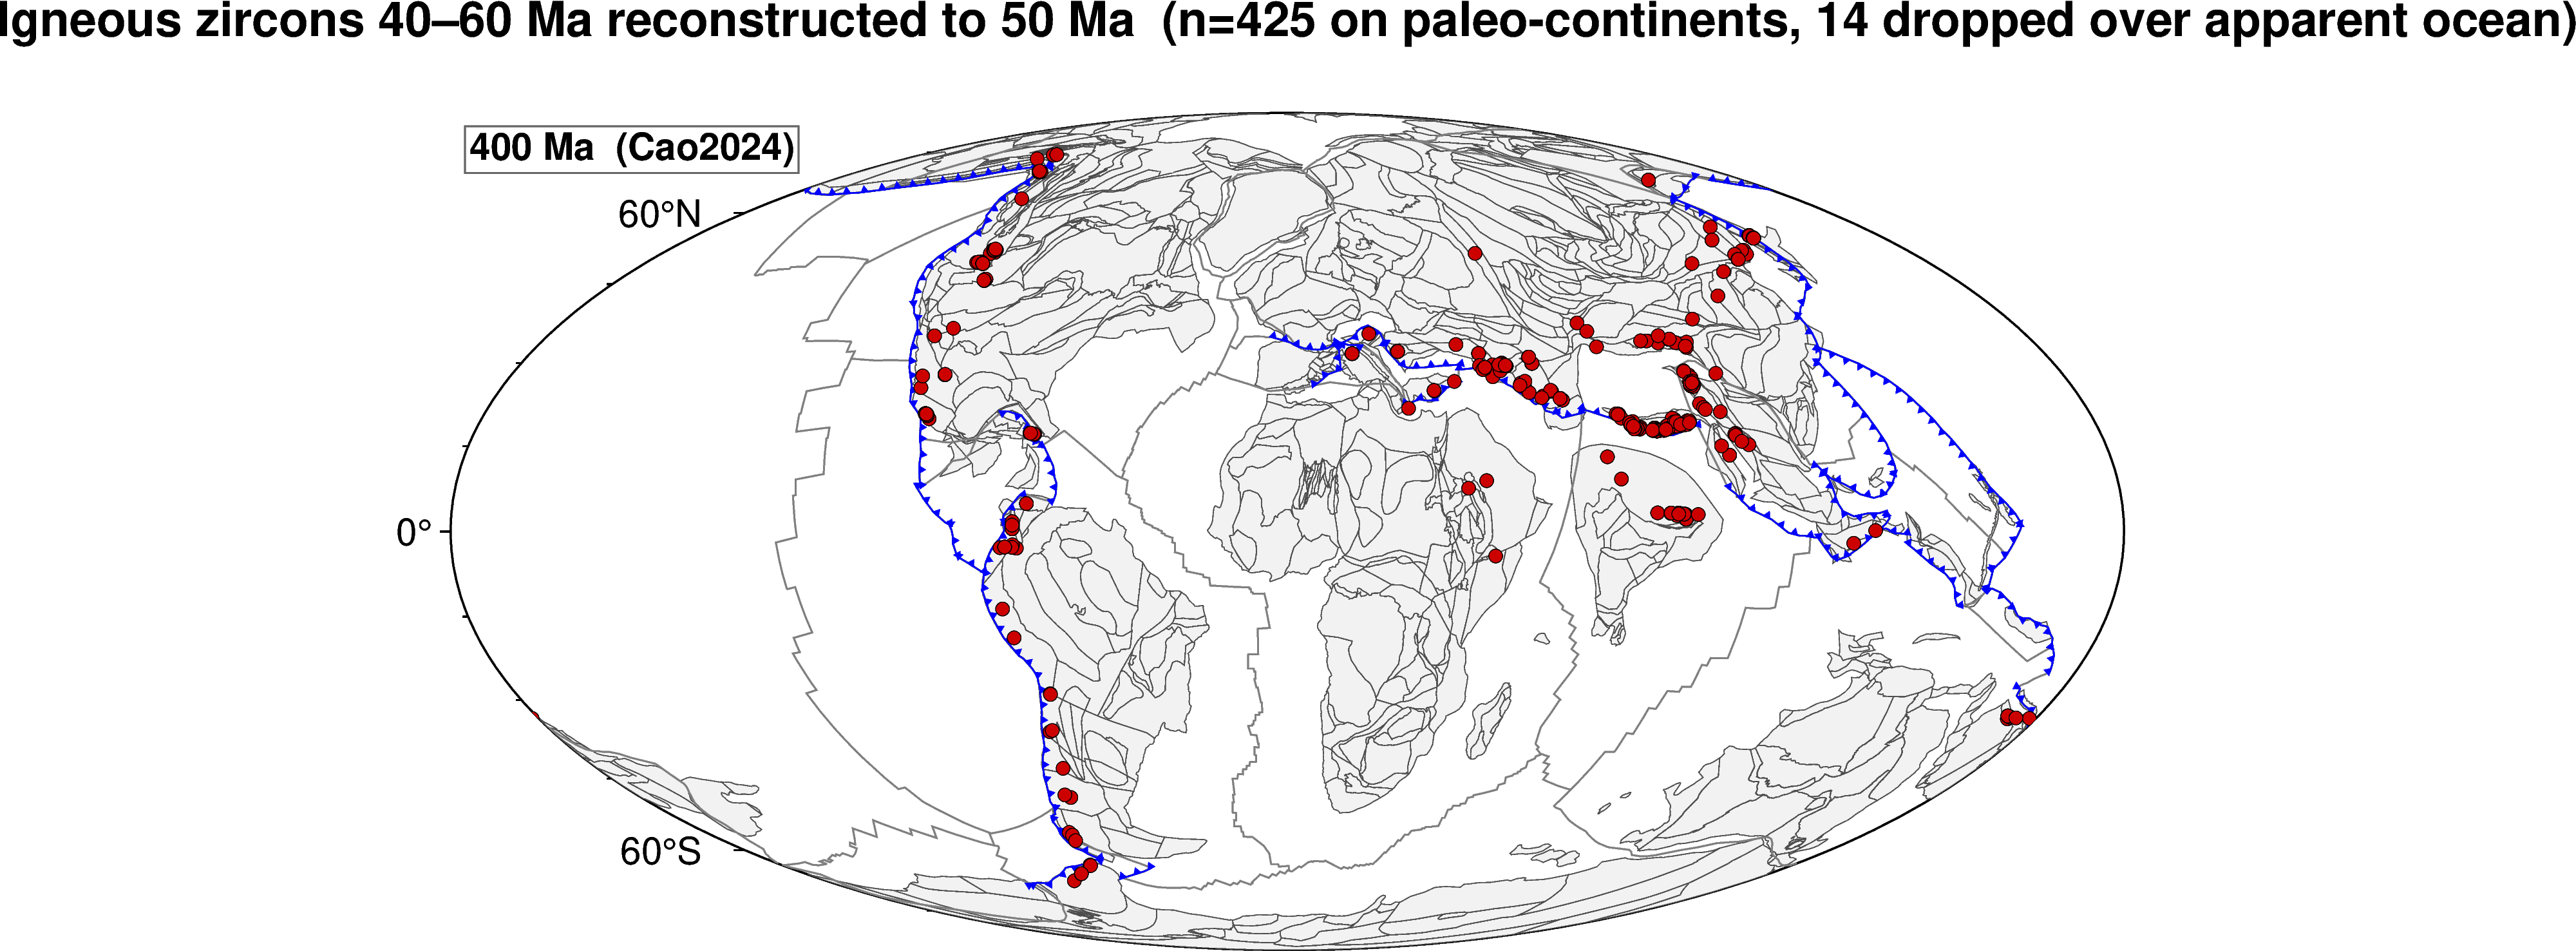

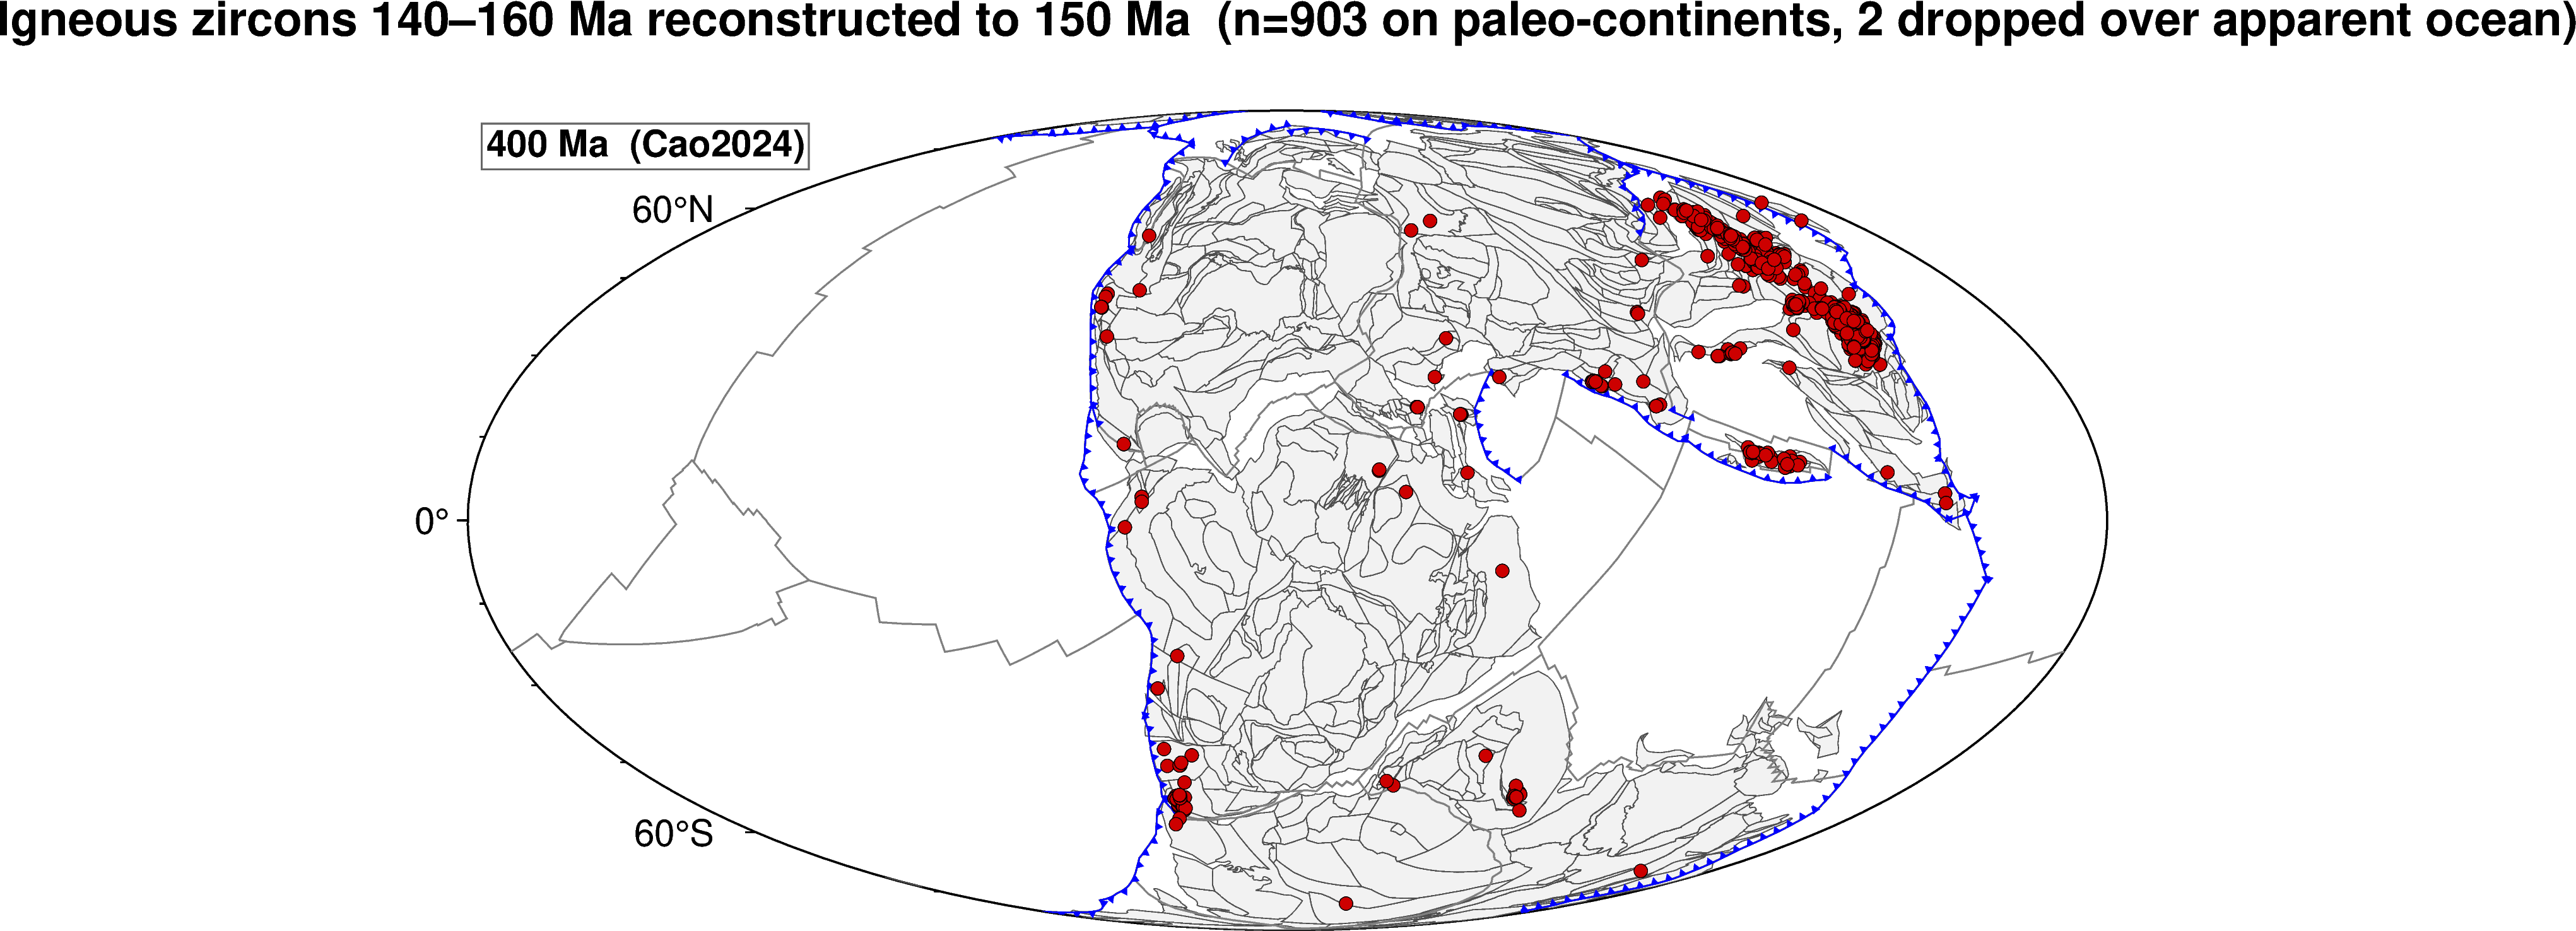

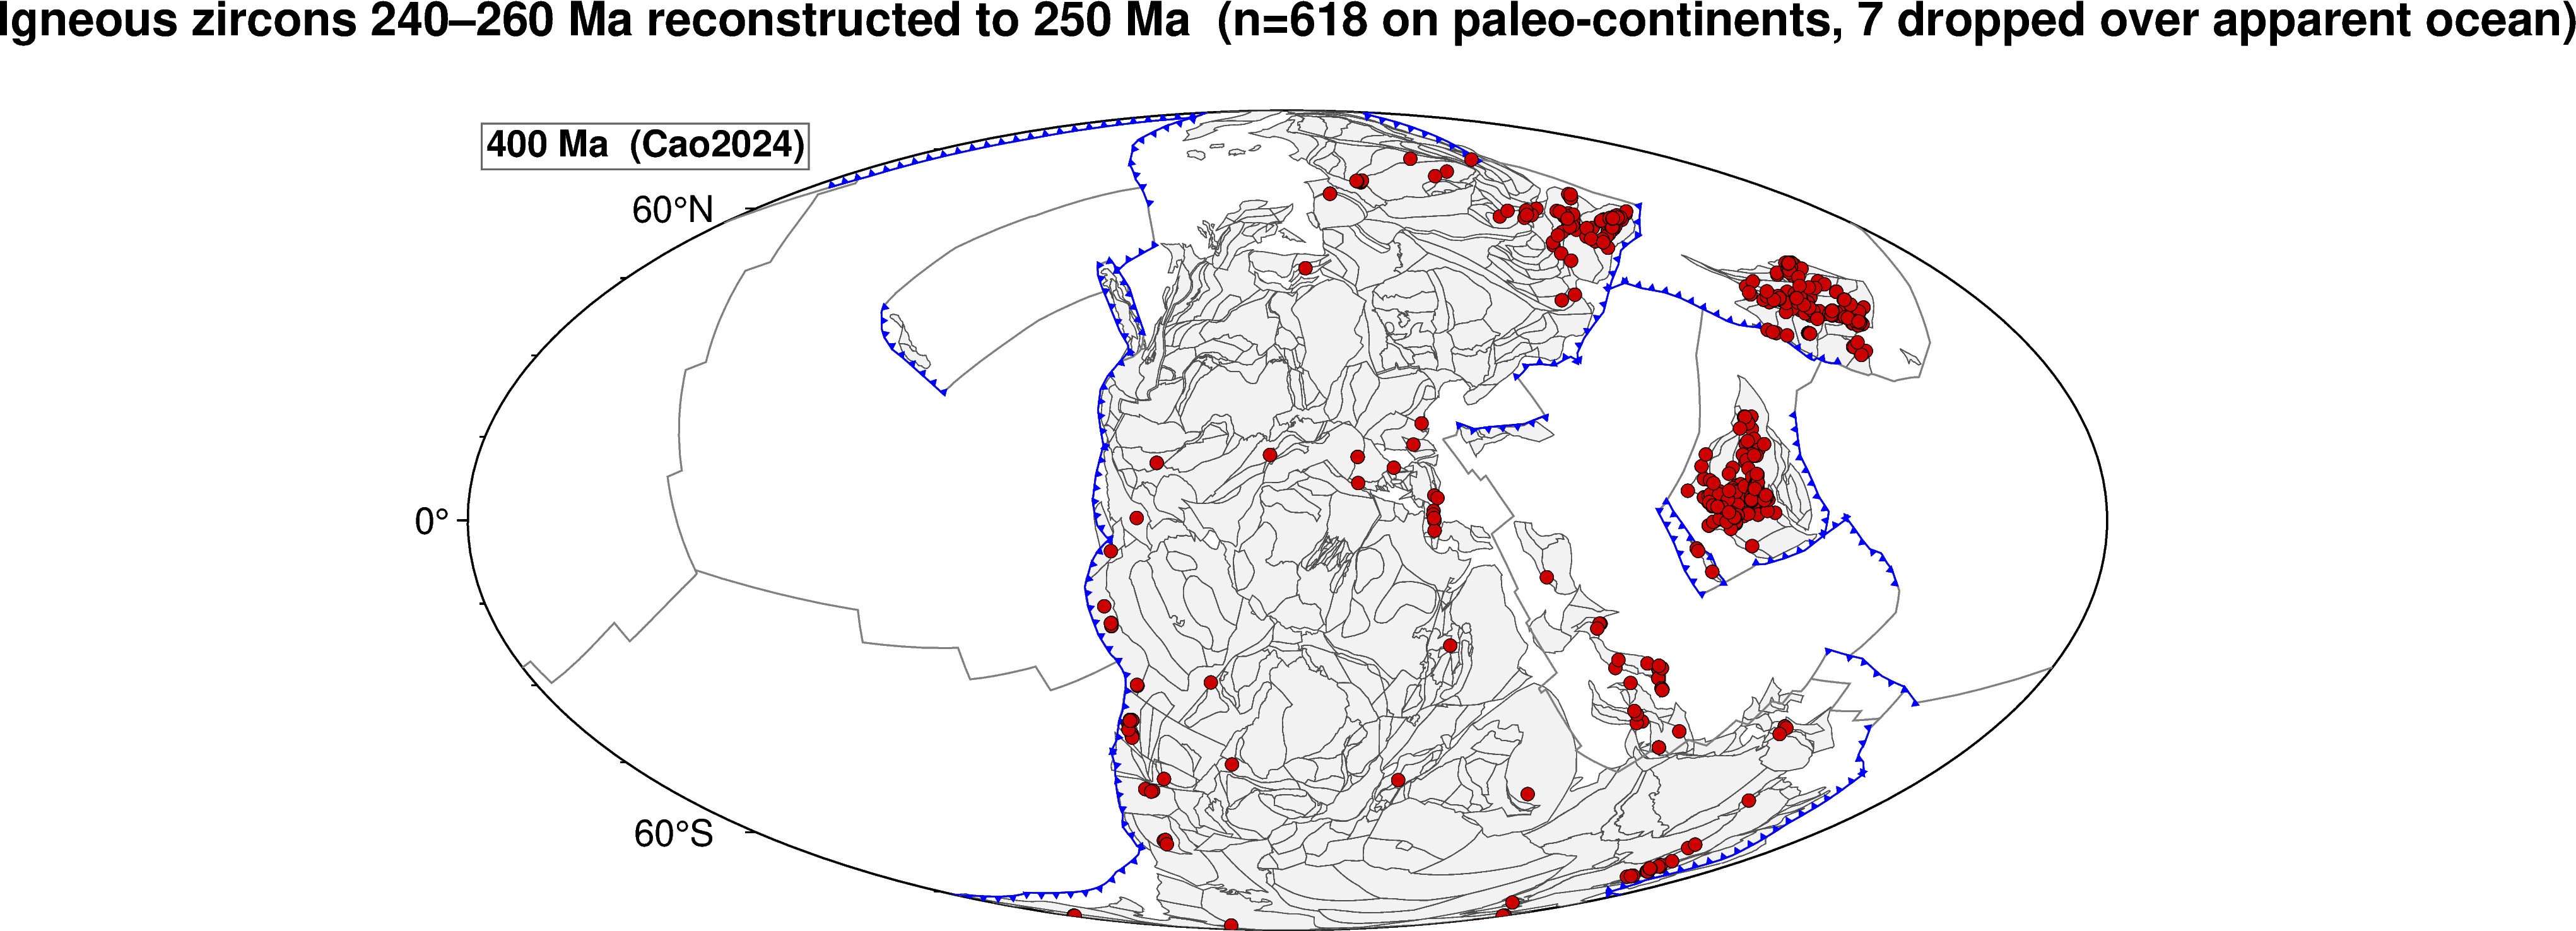

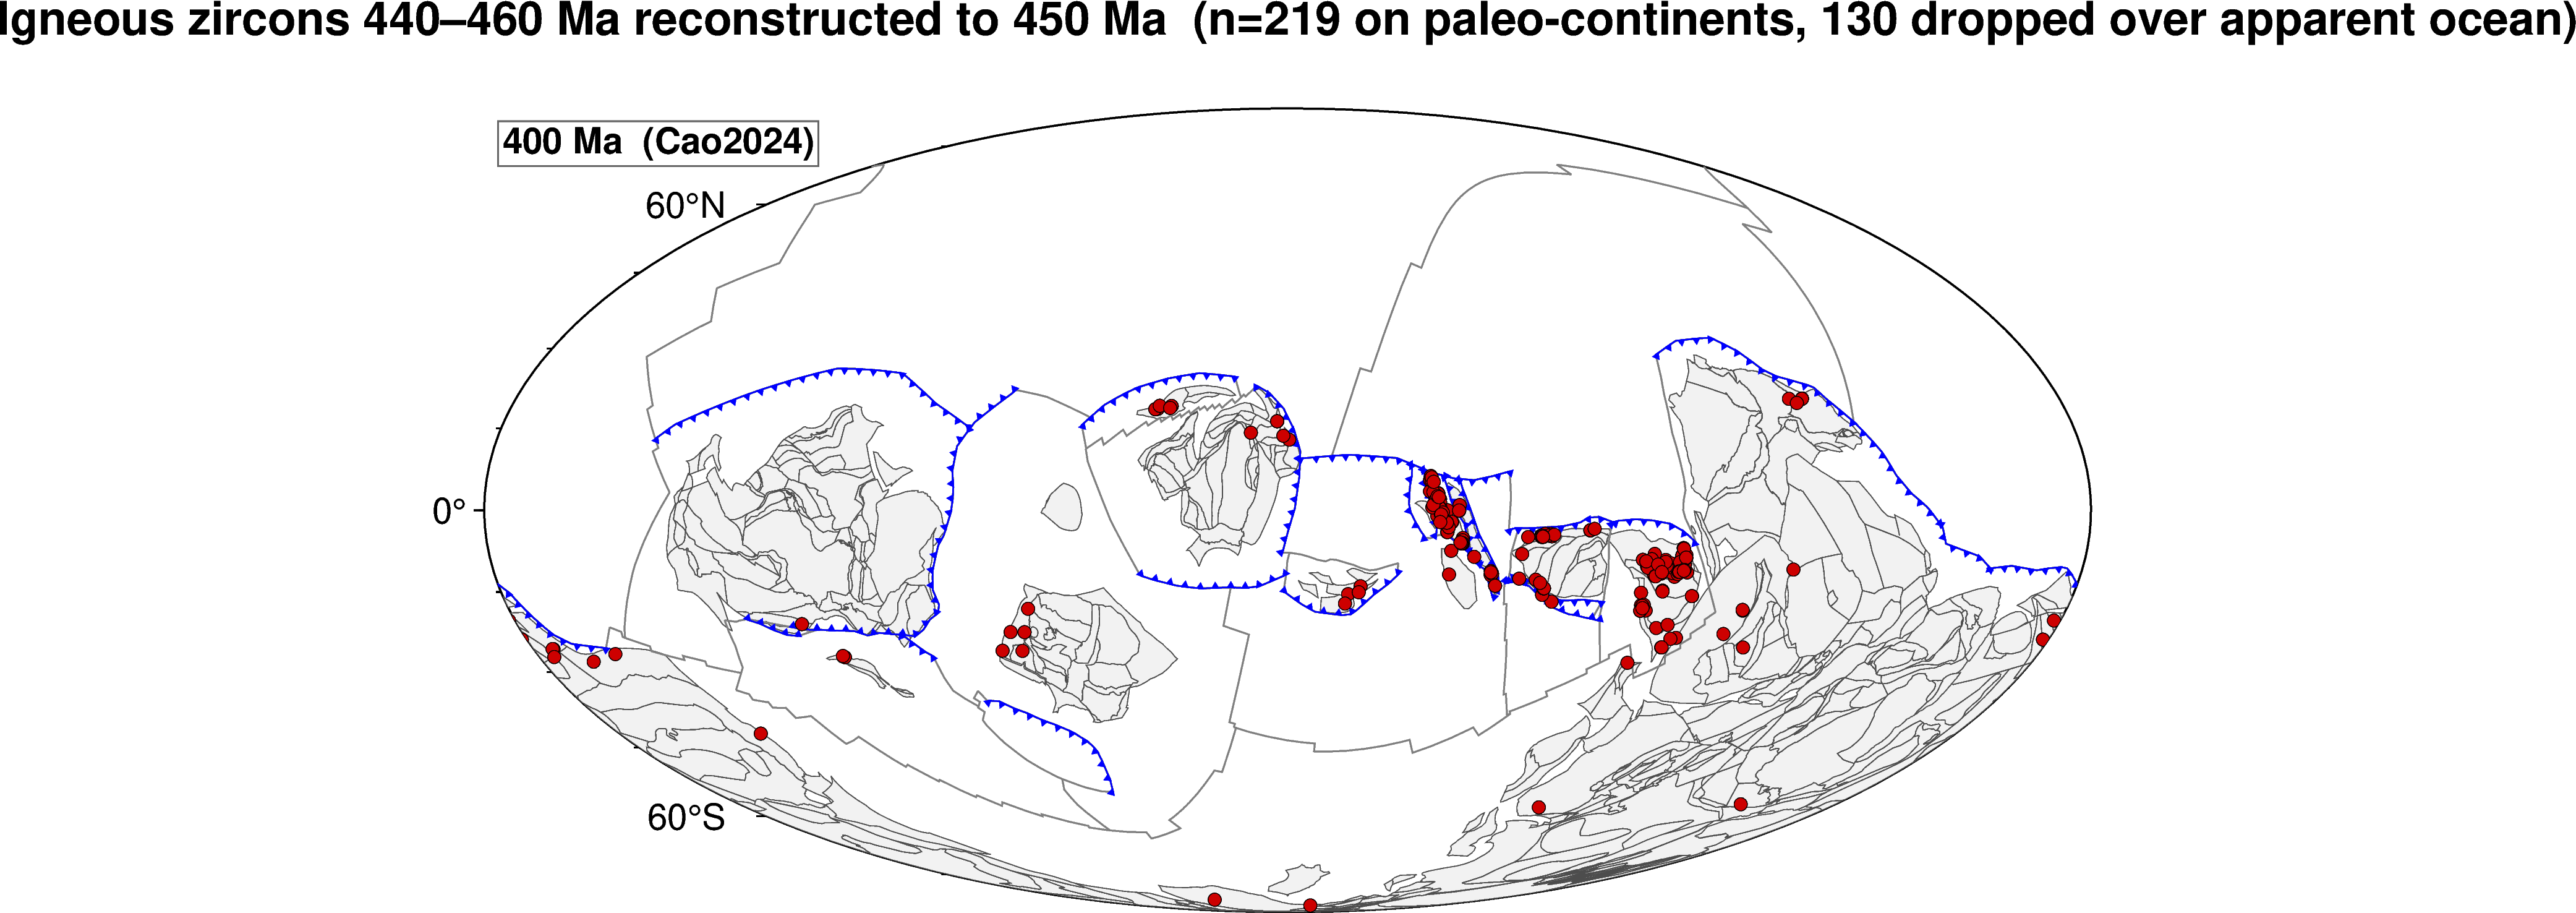

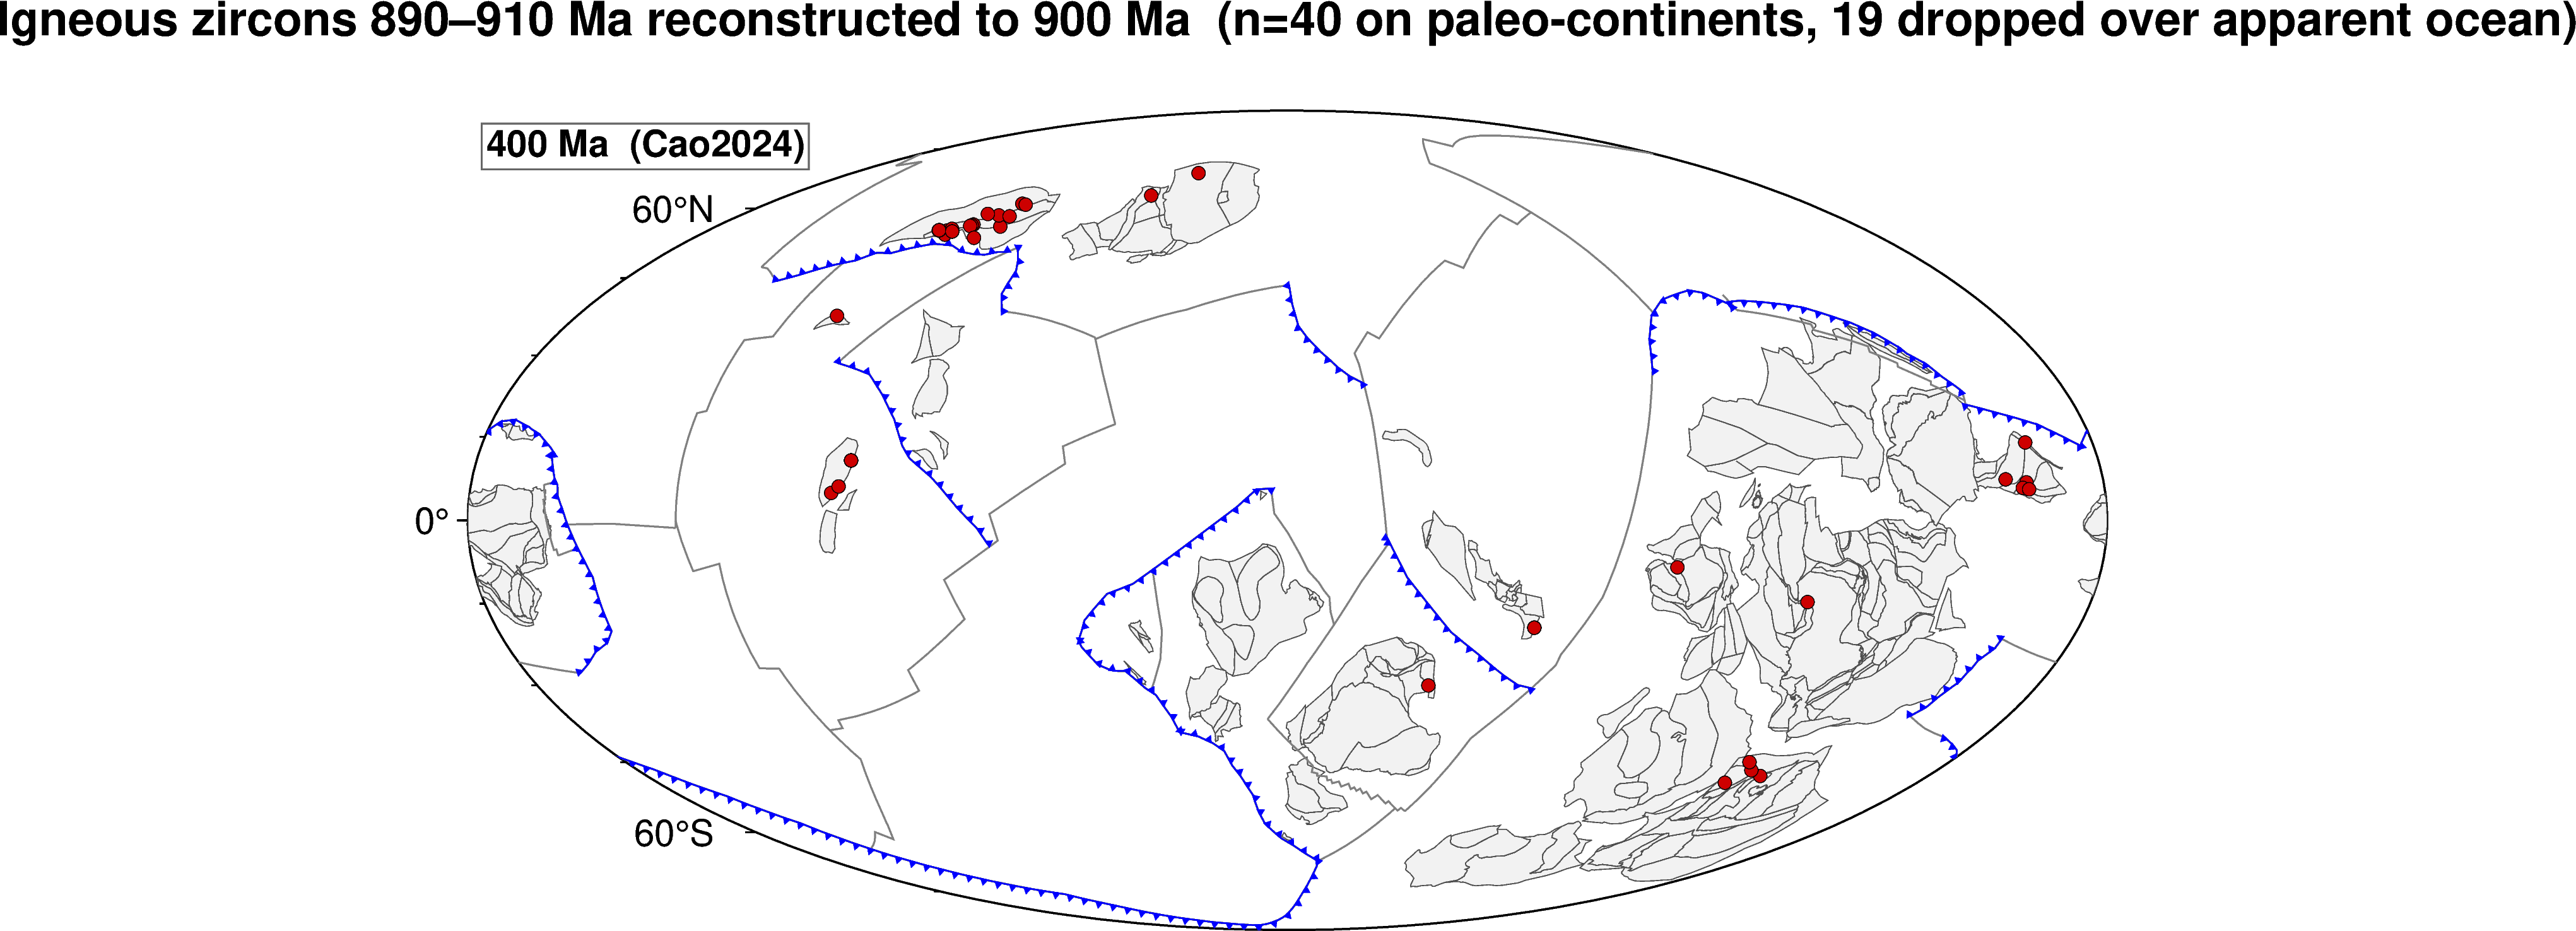

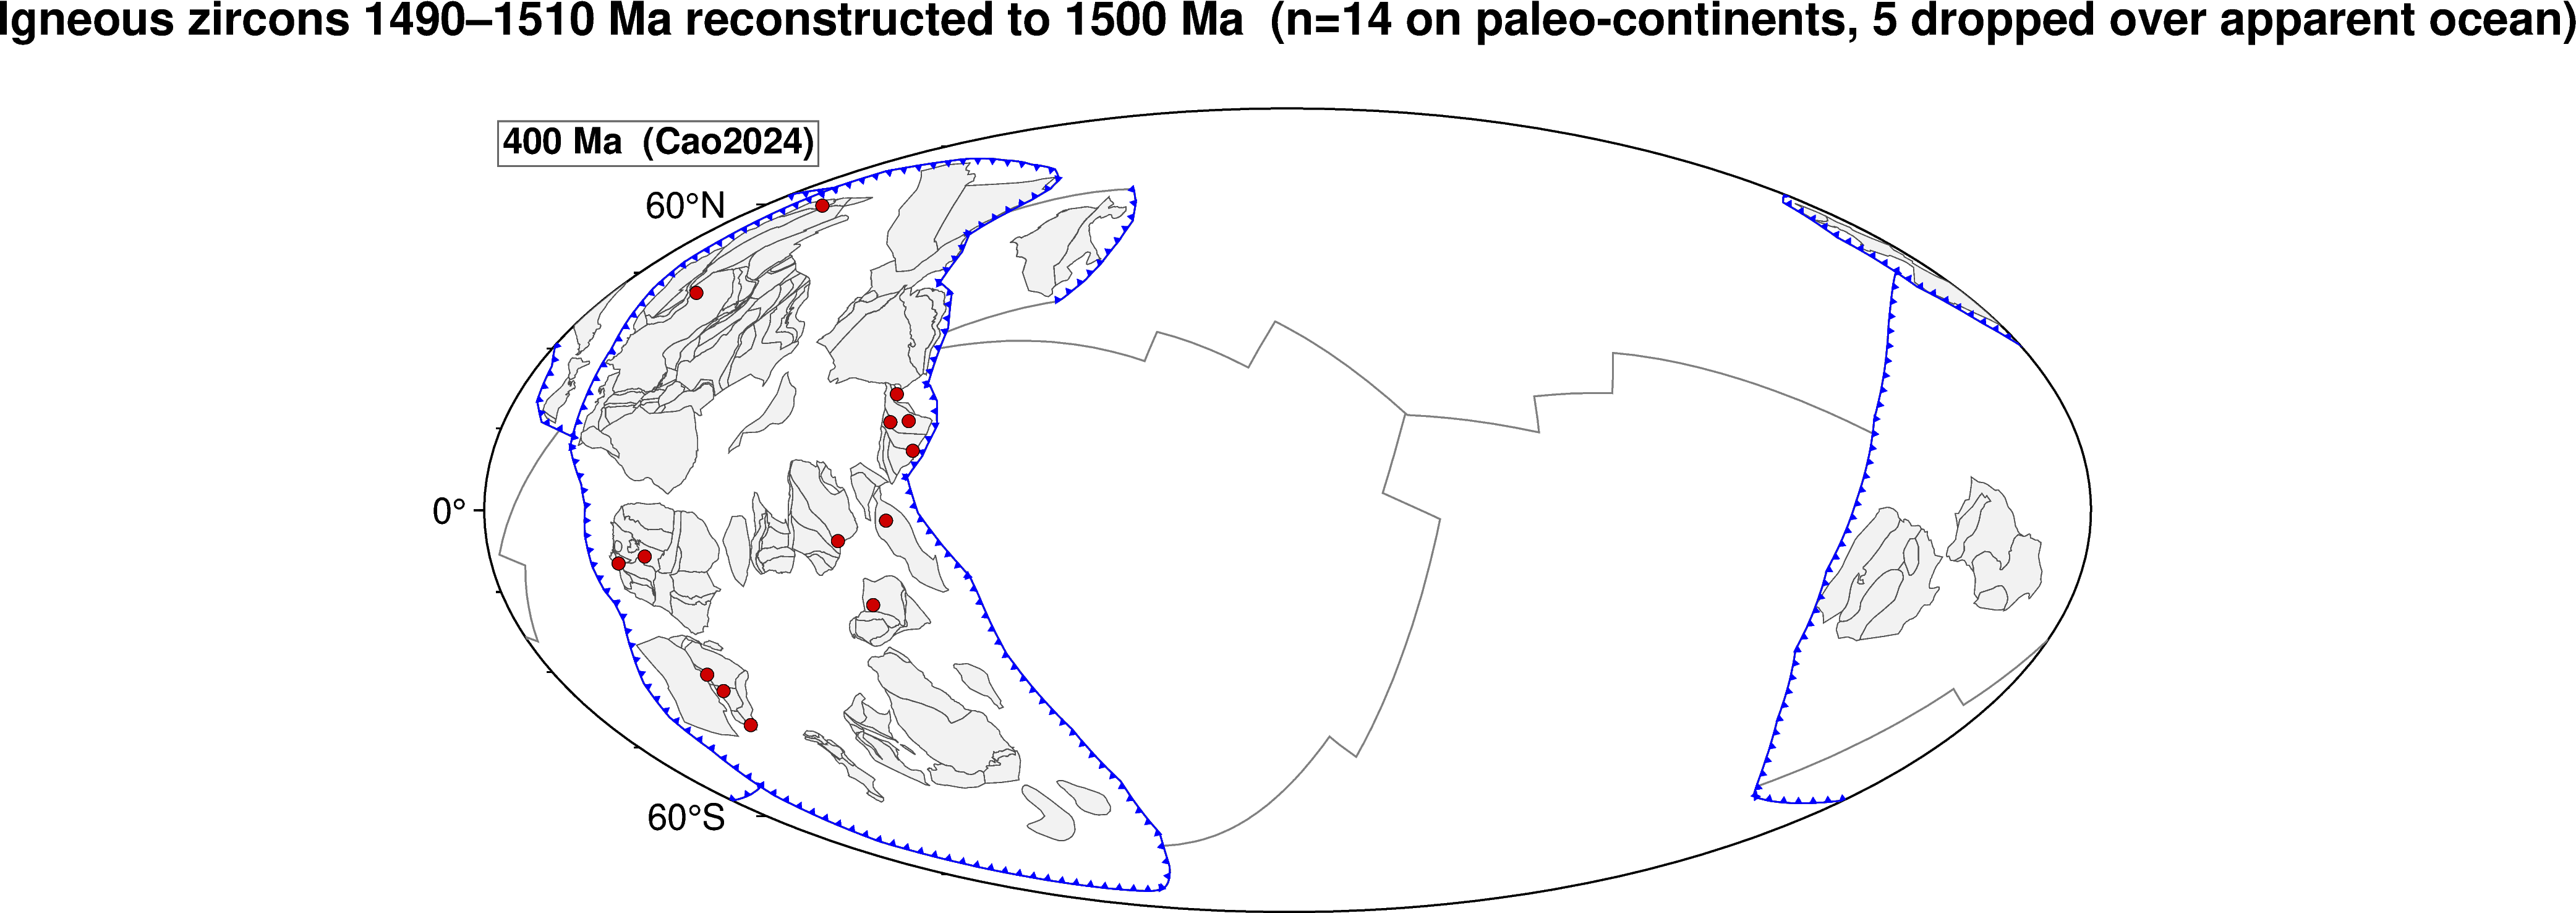

In [7]:
# Cell 6 — render six large individual maps
for t in [50, 150, 250, 450, 900, 1500]:
    fig = render_paleo_zircon_map(t, half_width=10)
    fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1100)
    display(HTML('<div style="height:1cm"></div>'))

## Interactive deep-time slider

The pattern follows T07: pre-render every frame to disk once, load the PNG bytes into a dict, then mutate a single `pn.pane.PNG`'s `.object` attribute on every slider change via `slider.param.watch`. The pre-render takes a few minutes the first time (Cao 2024 topology resolution dominates); after that the frames live in `./zircon_panel_cache/` and the slider is instantaneous.

Default cadence is **every 50 Myr from 0 to 1800 Ma** (37 frames). Drop `STEP` to 25 for a smoother slider at the cost of a longer pre-render.

In [8]:
# Cell 7 — pre-render PNG frames for the slider
import panel as pn
pn.extension()

CACHE = Path("./igneous_panel_cache_v1"); CACHE.mkdir(exist_ok=True)  # bumped from _v2 after switching to per-polygon shapely-against-rendered-cgdf filter (fixes residual deep-time supercontinent leak)
STEP  = 50                              # Myr between frames
TIMES = list(range(0, 1801, STEP))
for t in TIMES:
    f = CACHE / f"igneous_panel_cache_{t:04d}.png"
    if f.exists(): continue
    fig = render_paleo_zircon_map(t, half_width=15, projection="W0/16c")
    fig.savefig(f, dpi=100)
    print(f"  rendered frame {t} Ma")
print(f"cached {len(TIMES)} frames in {CACHE}")

cached 37 frames in igneous_panel_cache_v1


Preloaded 37 frames into memory


Column
    [0] PNG(bytes, width=900)
    [1] IntSlider(end=1800, label='Age (Ma)', name='Age (Ma)', step=50)
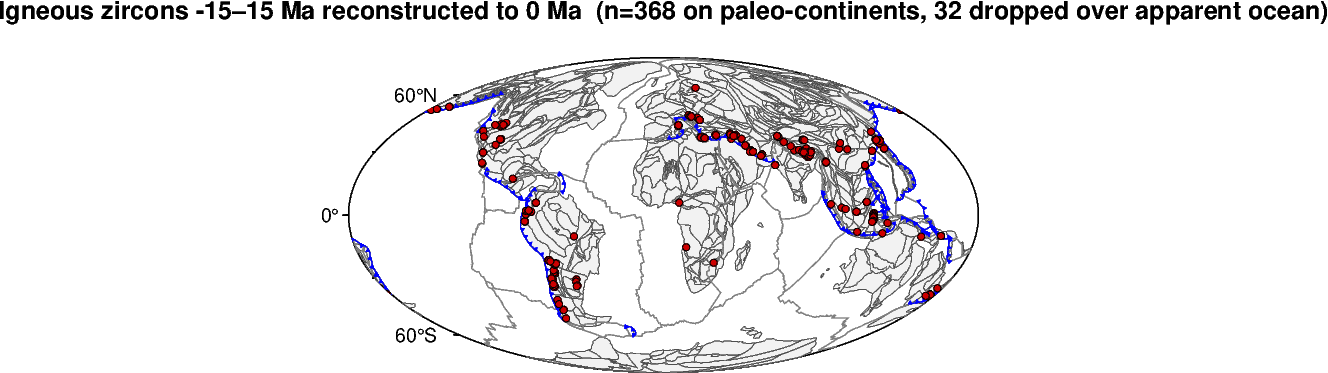

In [9]:
# Cell 8 — panel slider
# Preload every frame's PNG bytes into a dict in memory, then mutate
# a single pn.pane.PNG's .object attribute on every slider change
# via slider.param.watch. This is the most reliable Panel pattern
# for a file-backed image switcher — it sidesteps:
#  • file-vs-URL caching at the browser layer (we never reference a
#    file path; the image content is updated in-memory)
#  • Panel's lazy reactive re-execution (`watch` fires synchronously)
#  • disk I/O cost on every drag of the slider
frame_bytes = {}
for _t in TIMES:
    _path = CACHE / f"igneous_panel_cache_{_t:04d}.png"
    if _path.exists():
        frame_bytes[_t] = _path.read_bytes()
print(f"Preloaded {len(frame_bytes)} frames into memory")

slider = pn.widgets.IntSlider(
    name="Age (Ma)", start=0, end=1800, step=STEP, value=0)
image_pane = pn.pane.PNG(object=frame_bytes[0], width=900)

def _update_image(event):
    if event.new in frame_bytes:
        image_pane.object = frame_bytes[event.new]
slider.param.watch(_update_image, "value")

pn.Column(image_pane, slider)

## Extend this

- **Stricter window**: drop `half_width` to 5 Myr to see only zircons born almost exactly at the reconstruction time — cleaner kinematic signal but fewer dots.
- **Disable the continental filter**: by default `render_paleo_zircon_map` drops zircons that reconstruct over apparent paleo-ocean (per-polygon `shapely.contains` test against the rendered `gplot.get_continents()` GeoDataFrame). Comment out the `sub = sub[_on_cont].copy()` line in cell 5 to plot every reconstructed position regardless of where it lands \u2014 useful for diagnosing which zircons / plate IDs are misbehaving in the Cao 2024 reconstruction.
- **Switch databases**: This notebook ships against the *igneous* subset. Repoint `ZIRCON_REL` at one of the other Wu 2023 (https://doi.org/10.5281/zenodo.7795705) files to render a different zircon population. Plate IDs and the .gpmlz schema are identical across the three files.
- **Source-area highlighting**: colour the zircon dots by `plate_id` (using a categorical CPT) to visualize which paleocontinents are contributing the most material at each age.
- **Pair with T13 / T15**: same notebook structure runs against the *detrital* (sedimentary) and *metamorphic* Wu 2023 subsets. Compare the three to see arc-magmatism flare-ups (igneous), collisional metamorphic belts (metamorphic), and the redistribution of those signals into sedimentary basins (detrital).

## References

- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing published plate-reconstruction models. *Zenodo*. https://github.com/michaelchin/plate-model-manager
- Wu, Y., Fang, X., Wang, Z., Yang, Y., Wang, R., Tang, Y., Han, F., Wu, F. & Liu, C. (2023). A global zircon U-Pb geochronology database compiled from published data sets. *Earth System Science Data* 15. https://doi.org/10.5194/essd-2023-141
- Cao, X., Collins, A.S., Pisarevsky, S., Flament, N., Li, S., Hasterok, D. & Müller, R.D. (2024). A deep-time Phanerozoic to Proterozoic plate motion model at 1° resolution. *Earth System Science Data* 16, 4007-4032. https://doi.org/10.5194/essd-16-4007-2024
- Jian, D., Williams, S.E., Yu, S. & Zhao, G. (2022). Quantifying the link between the detrital zircon record and tectonic settings. *J. Geophys. Res. Solid Earth* 127, e2022JB024606. https://doi.org/10.1029/2022JB024606
- Holoviz authors (2024). Panel: A high-level app and dashboarding solution for Python. https://panel.holoviz.org